In [1]:
import glob

images = glob.glob("../data/PNG/preprocessed/*")

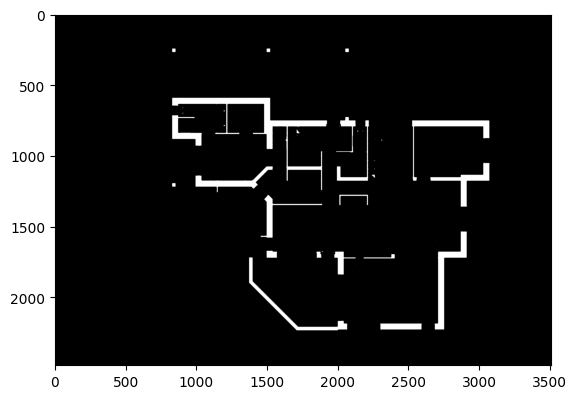

In [2]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(images[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")
plt.show()

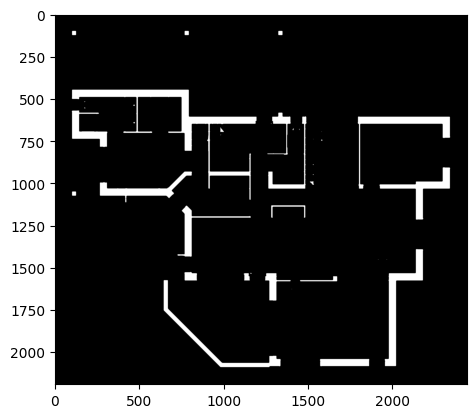

In [3]:
import numpy as np

padding = 100

# Find bounding box of all non-zero (white) pixels
coords = cv2.findNonZero(gray)
if coords is None:
    raise ValueError("No white content found in the image.")

x, y, w, h = cv2.boundingRect(coords)

# Add padding, clamped to image bounds
H, W = img.shape[:2]
x1 = max(0, x - padding)
y1 = max(0, y - padding)
x2 = min(W, x + w + padding)
y2 = min(H, y + h + padding)

cropped = img[y1:y2, x1:x2]
plt.imshow(cropped, cmap="gray")
plt.show()

In [4]:
import os


def crop_and_pad(img, padding=100):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    coords = cv2.findNonZero(gray)
    if coords is None:
        raise ValueError("No white content found in the image.")

    x, y, w, h = cv2.boundingRect(coords)

    # Add padding, clamped to image bounds
    H, W = img.shape[:2]
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(W, x + w + padding)
    y2 = min(H, y + h + padding)

    cropped = img[y1:y2, x1:x2]
    return cropped


for img_path in images:
    img = cv2.imread(img_path)
    cropped = crop_and_pad(img)

    if not os.path.exists("../data/PNG/crop_and_pad"):
        os.makedirs("../data/PNG/crop_and_pad")
    cv2.imwrite(
        os.path.join("../data/PNG/crop_and_pad", os.path.basename(img_path)), cropped
    )

    # fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # axes[0].imshow(img)
    # axes[0].set_title('Original')
    # axes[1].imshow(cropped)
    # axes[1].set_title('Cropped')
    # plt.show()